<a href="https://colab.research.google.com/github/IbrahimHanafy2222/Computer-Vision-Project/blob/main/bonus/webcam_trials/train_option_b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Option B — Landmark MLP (MediaPipe features, no pixels)
Runs MediaPipe HandLandmarker on ASL Alphabet training images offline,
extracts 21 3D joint positions, normalises them, trains a scikit-learn MLP.

**Why this works:** completely invariant to lighting, background, skin tone, camera quality.
MediaPipe sees the same 21 joints regardless of appearance.

Output: `models/optionB.pkl` — joblib bundle with mlp + scaler + classes

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Install & Imports

In [2]:
!pip install -q kaggle mediapipe scikit-learn joblib

import os, random, joblib
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

print('mediapipe:', mp.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 14.2 MB/s eta 0:00:00
mediapipe: 0.10.35


## 2. Download Dataset + Hand Model

In [3]:
# ASL Alphabet real photos
if not os.path.exists('asl_alphabet_train'):
    os.environ['KAGGLE_USERNAME'] = 'abdullahashiry'
    os.environ['KAGGLE_KEY']      = 'KGAT_331632d901a6cb7a05431b55135bd8c2'
    !kaggle datasets download -d grassknoted/asl-alphabet --unzip

# MediaPipe hand landmarker
HAND_MODEL = 'hand_landmarker.task'
if not os.path.exists(HAND_MODEL):
    !wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task
    print('Downloaded hand_landmarker.task')

TRAIN_DIR   = 'asl_alphabet_train/asl_alphabet_train'
ALL_CLASSES = sorted([c for c in os.listdir(TRAIN_DIR) if len(c) == 1 and c.isalpha()])
print(f'{len(ALL_CLASSES)} classes: {ALL_CLASSES}')

Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
100% 1.03G/1.03G [01:00<00:00, 18.3MB/s]

Downloaded hand_landmarker.task
26 classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


## 3. Extract Landmarks from All Images
MediaPipe processes each image and extracts 21 3D hand joint positions.
Images where no hand is detected are skipped.

In [4]:
def landmarks_to_features(lm_list):
    """21 landmarks → 63-dim normalised vector. Invariant to scale/position."""
    pts = np.array([[lm.x, lm.y, lm.z] for lm in lm_list], dtype=np.float32)
    pts -= pts[0]                     # translate: wrist at origin
    scale = np.linalg.norm(pts[9])   # wrist→middle-finger-MCP distance
    if scale > 1e-6:
        pts /= scale
    return pts.flatten()              # (63,)


# Build hand detector (IMAGE mode for offline batch processing)
hand_options = mp_vision.HandLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=HAND_MODEL),
    running_mode=mp_vision.RunningMode.IMAGE,
    num_hands=1,
    min_hand_detection_confidence=0.4,   # lower threshold — controlled photos
)
detector = mp_vision.HandLandmarker.create_from_options(hand_options)

X_feats, y_labels = [], []
skipped = 0

for cls in tqdm(ALL_CLASSES, desc='Classes'):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    cls_idx = ALL_CLASSES.index(cls)
    images  = [f for f in os.listdir(cls_dir)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    # Sample up to 2000 per class for speed (full = 3000)
    images  = random.sample(images, min(2000, len(images)))

    for fname in images:
        path = os.path.join(cls_dir, fname)
        try:
            mp_img  = mp.Image.create_from_file(path)
            result  = detector.detect(mp_img)
            if result.hand_landmarks:
                feats = landmarks_to_features(result.hand_landmarks[0])
                X_feats.append(feats)
                y_labels.append(cls_idx)
            else:
                skipped += 1
        except Exception:
            skipped += 1

detector.close()

X = np.array(X_feats, dtype=np.float32)
y = np.array(y_labels, dtype=np.int32)
print(f'\nExtracted: {len(X)} samples  Skipped (no hand): {skipped}')
print(f'Feature shape: {X.shape}   (21 joints × 3 axes = 63)')

Classes:   0%|          | 0/26 [00:00<?, ?it/s]


Extracted: 40891 samples  Skipped (no hand): 11109
Feature shape: (40891, 63)   (21 joints × 3 axes = 63)


## 4. Detection Rate per Class

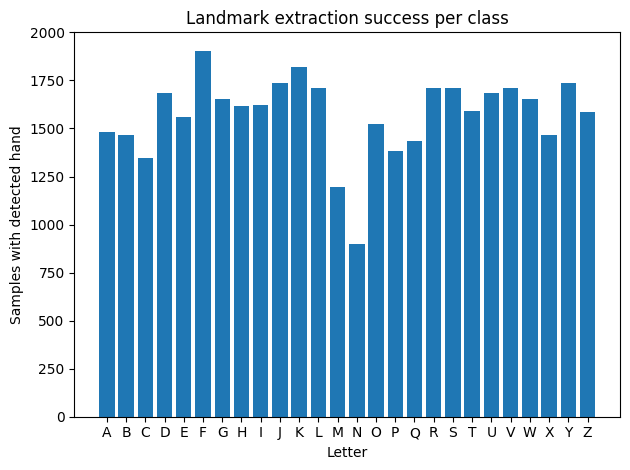

In [5]:
from collections import Counter
counts = Counter(y)
cls_names = [ALL_CLASSES[i] for i in sorted(counts)]
cls_counts = [counts[i] for i in sorted(counts)]
plt.bar(cls_names, cls_counts)
plt.xlabel('Letter'); plt.ylabel('Samples with detected hand')
plt.title('Landmark extraction success per class')
plt.tight_layout(); plt.show()

## 5. Train MLP Classifier

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('Training MLP...')
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
    verbose=True,
)
mlp.fit(X_train, y_train)

y_pred  = mlp.predict(X_test)
acc     = accuracy_score(y_test, y_pred)
print(f'\nTest accuracy: {acc*100:.2f}%')

Training MLP...
Iteration 1, loss = 0.79579855
Validation score: 0.939010
Iteration 2, loss = 0.15261408
Validation score: 0.971519
Iteration 3, loss = 0.10578607
Validation score: 0.963176
Iteration 4, loss = 0.08105884
Validation score: 0.975834
Iteration 5, loss = 0.06986664
Validation score: 0.978711
Iteration 6, loss = 0.05961191
Validation score: 0.976985
Iteration 7, loss = 0.05592145
Validation score: 0.981013
Iteration 8, loss = 0.04908920
Validation score: 0.979574
Iteration 9, loss = 0.04359115
Validation score: 0.981876
Iteration 10, loss = 0.03933169
Validation score: 0.983314
Iteration 11, loss = 0.03498449
Validation score: 0.980725
Iteration 12, loss = 0.03498282
Validation score: 0.973820
Iteration 13, loss = 0.03358400
Validation score: 0.983314
Iteration 14, loss = 0.02735204
Validation score: 0.984465
Iteration 15, loss = 0.02754345
Validation score: 0.982451
Iteration 16, loss = 0.02605963
Validation score: 0.982451
Iteration 17, loss = 0.02426222
Validation score:

## 6. Classification Report

              precision    recall  f1-score   support

           A       1.00      0.99      0.99       222
           B       1.00      1.00      1.00       220
           C       1.00      1.00      1.00       202
           D       1.00      1.00      1.00       252
           E       0.99      1.00      1.00       234
           F       0.99      0.99      0.99       286
           G       0.98      1.00      0.99       248
           H       1.00      0.99      1.00       243
           I       0.99      0.98      0.99       243
           J       0.99      1.00      0.99       260
           K       1.00      0.99      0.99       273
           L       1.00      0.99      0.99       256
           M       0.97      0.95      0.96       179
           N       0.92      0.97      0.94       135
           O       0.98      0.99      0.99       228
           P       1.00      0.99      0.99       208
           Q       0.98      1.00      0.99       215
           R       0.99    

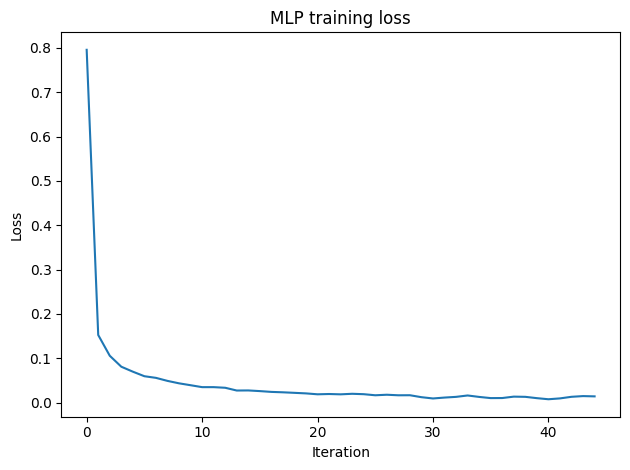

In [7]:
print(classification_report(y_test, y_pred, target_names=ALL_CLASSES))

# Loss curve
plt.plot(mlp.loss_curve_)
plt.xlabel('Iteration'); plt.ylabel('Loss')
plt.title('MLP training loss')
plt.tight_layout(); plt.show()

## 7. Save Model

In [8]:
bundle = {
    'mlp':     mlp,
    'scaler':  scaler,
    'classes': np.array(ALL_CLASSES),   # index → letter string
}
joblib.dump(bundle, 'optionB.pkl')
print(f'Saved: optionB.pkl  ({os.path.getsize("optionB.pkl")/1e3:.0f} KB)')
print(f'Classes: {ALL_CLASSES}')

Saved: optionB.pkl  (722 KB)
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


## 8. Copy to Drive

In [9]:
import shutil

OUT = '/content/drive/MyDrive/CV552_SignLanguage/tflite'
os.makedirs(OUT, exist_ok=True)
shutil.copy('optionB.pkl', os.path.join(OUT, 'optionB.pkl'))
print(f'Saved to {OUT}')
print('\nNext: download optionB.pkl → bonus/webcam_trials/models/optionB.pkl')

Saved to /content/drive/MyDrive/CV552_SignLanguage/tflite

Next: download optionB.pkl → bonus/webcam_trials/models/optionB.pkl
